In [1]:
import pandas as pd
import re, os, json
from tqdm.notebook import tqdm

In [2]:
df_test = pd.read_excel('FAERS-ETHER-WHOLE.xlsx')
df_test.shape

(134478, 6)

In [3]:
# Label Normalizer to FAERS R4
Label_pool = {'AE': 'AE',
             'TEMPO': 'TEMPO',
             'SDRUG': 'DRUG',
             'DRUG': 'DRUG',
             'STATUS': 'STATUS',
             'CDRUG': 'DRUG',
             'BSYM': 'DX',
             'DOSE': 'DOSE',
             'LAB': 'LAB',
             'HX': 'HX',
             'TREATMENT': 'DX',
             'SEX': 'SEX',
             'AGE': 'AGE',
             'MHX': 'HX',
             'DX': 'DX',
             'DIAGNOSIS': 'DX',
             'MAE': 'AE',
             'FHX': 'HX',
             'COD': 'AE',
             'BYSM': 'HX',
             'DIAGNOSES': 'DX',
             
             'DATE':'TEMPO',
             'IND':'INDICATION',
             'ODRUG':'DRUG',
             'DURATION': 'TEMPO',
             'TIME': 'TEMPO',
             'TEMPORAL': 'TEMPO',
             'RELATIVE': 'TEMPO',
             'LATENCY': 'TEMPO',   
             'FREQUENCY': 'TEMPO',
             'BASELINE SYMPTOM': 'BSYM',
             'CAUSE OF DEATH': 'COD',
             'MEDICAL HISTORY':'HX',
             'FAMILY HISTORY':'HX',
             'R/O':'RO',
             'RO':'RO',

             'SYMPTOM': 'AE',
             'SECOND_LEVEL_DIAGNOSIS': 'DX',
             'MEDICAL_HISTORY': 'HX',
             'CAUSE_OF_DEATH': 'COD',
             'VACCINE': 'OTHERS',
             'RULE_OUT': 'RO',
             'FAMILY_HISTORY': 'HX'
             }

df_test['Label_Norm'] = [Label_pool.get(d['Label'].upper(),'OTHERS') for _, d in df_test.iterrows()]

In [23]:
df_test['Label_Norm'].unique()

array(['AGE', 'SEX', 'DRUG', 'DOSE', 'TEMPO', 'HX', 'AE', 'LAB', 'DX',
       'STATUS', 'COD', 'OTHERS', 'RO', 'BSYM'], dtype=object)

In [24]:
df_test[df_test['Note']=='ETHER']

,File,Note,Start,End,Label,Text,Label_Norm
132,16342363-1.json,ETHER,36,84,SYMPTOM,Non-Interventional Study report (baricitinib-psp,AE
133,16342363-1.json,ETHER,69,80,DRUG,baricitinib,DRUG
134,16342363-1.json,ETHER,302,314,DRUG,atorvastatin,DRUG
135,16342363-1.json,ETHER,315,322,SYMPTOM,calcium,AE
136,16342363-1.json,ETHER,347,356,DRUG,doxazosin,DRUG
...,...,...,...,...,...,...,...
134473,12707367-2.json,ETHER,2690,2700,DRUG,Amlodipine,DRUG
134474,12707367-2.json,ETHER,2702,2746,SYMPTOM,absent or below the quantification threshold,AE
134475,12707367-2.json,ETHER,2764,2774,DRUG,Amlodipine,DRUG
134476,12707367-2.json,ETHER,2816,2826,DRUG,Amlodipine,DRUG


## Final Analyses - Test Dataset is ready 

In [8]:
import pandas as pd

def spans_overlap(a_start, a_end, b_start, b_end):
    """
    Returns True if two spans overlap at all.
    Treat spans as [start, end) intervals.
    """
    return (a_start < b_end) and (b_start < a_end)


def compute_counts_for_system(tmp_df: pd.DataFrame, system_note: str):
    """
    Compute M, C, S, N for a given system (e.g., 'BERT' or 'LLM')
    compared to Human annotations, per Label_Norm and overall TOTAL.
    """
    df = tmp_df[tmp_df['Note'].isin(['Human', system_note])].copy()

    label_list = sorted(df['Label_Norm'].unique())
    counts = {label: {'M': 0, 'C': 0, 'S': 0, 'N': 0} for label in label_list}
    counts['TOTAL'] = {'M': 0, 'C': 0, 'S': 0, 'N': 0}

    for file_id in df['File'].unique():
        file_df = df[df['File'] == file_id]

        for label in label_list:
            sub = file_df[file_df['Label_Norm'] == label]

            human_spans_df = sub[sub['Note'] == 'Human'][['Start', 'End']].drop_duplicates()
            sys_spans_df   = sub[sub['Note'] == system_note][['Start', 'End']].drop_duplicates()

            human_spans = [
                {'start': int(row.Start), 'end': int(row.End), 'matched': False}
                for row in human_spans_df.itertuples(index=False)
            ]
            sys_spans = [
                {'start': int(row.Start), 'end': int(row.End), 'matched': False}
                for row in sys_spans_df.itertuples(index=False)
            ]

            # 1) Exact matches (M)
            for h in human_spans:
                for s in sys_spans:
                    if (not h['matched'] and not s['matched'] and
                        h['start'] == s['start'] and h['end'] == s['end']):
                        h['matched'] = True
                        s['matched'] = True
                        counts[label]['M'] += 1
                        break  # move to next human span

            # 2) Partial matches (C) – overlapping but not exact and unused
            for h in human_spans:
                if h['matched']:
                    continue
                for s in sys_spans:
                    if s['matched']:
                        continue
                    if spans_overlap(h['start'], h['end'], s['start'], s['end']):
                        h['matched'] = True
                        s['matched'] = True
                        counts[label]['C'] += 1
                        break  # move to next human span

            # 3) False negatives (N): human spans not matched at all
            for h in human_spans:
                if not h['matched']:
                    counts[label]['N'] += 1

            # 4) False positives (S): system spans not matched at all
            for s in sys_spans:
                if not s['matched']:
                    counts[label]['S'] += 1

    # Fill TOTAL as sum across labels
    for label in label_list:
        for key in ['M', 'C', 'S', 'N']:
            counts['TOTAL'][key] += counts[label][key]

    return counts


def counts_to_metrics_df(counts: dict, model_name: str, methods = 'Weighted') -> pd.DataFrame:
    """
    Convert counts dict {label: {'M','C','S','N'}} to a DataFrame with
    M_, C_, S_, N_ and Precision / Recall / F1.
    """
    rows = []
    for label, c in counts.items():
        M = c['M']
        C = c['C']
        S = c['S']
        N = c['N']

        # Revised M', C', S', N' (using your formula)
        M_ = M + (0.5 * C)
        C_ = 0.5 * C
        S_ = 0.25 * S
        N_ = N

        if methods == 'Weighted':
            precision = M_ / (M_ + C_ + S_) if (M_ + C_ + S_) > 0 else 0.0
            recall    = M_ / (M_ + C_ + N_) if (M_ + C_ + N_) > 0 else 0.0
        else:
            precision = M / (M + C + S) if (M + C + S) > 0 else 0.0
            recall    = M / (M + C + N) if (M + C + N) > 0 else 0.0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            'Model': model_name,
            'Label_Norm': label,
            'M': M,
            'C': C,
            'S': S,
            'N': N,
            'M_': M_,
            'C_': C_,
            'S_': S_,
            'N_': N_,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })

    # Order labels alphabetically, TOTAL at the bottom
    labels = sorted([lbl for lbl in counts.keys() if lbl != 'TOTAL']) + ['TOTAL']
    df = pd.DataFrame(rows)
    df['Label_Norm'] = pd.Categorical(df['Label_Norm'], categories=labels, ordered=True)
    df = df.sort_values(['Model', 'Label_Norm']).reset_index(drop=True)
    return df

In [9]:
label_human = df_test[df_test['Note']=='Human']['Label_Norm'].unique()
label_human = [x for x in label_human if x != 'TEMPO']
label_human

['AGE',
 'SEX',
 'DRUG',
 'DOSE',
 'HX',
 'AE',
 'LAB',
 'DX',
 'STATUS',
 'OTHERS',
 'COD',
 'BSYM',
 'RO']

In [15]:
label_human = ['AGE', 'SEX', 'DRUG', 'DOSE', 'HX', 'AE', 'LAB', 'DX', 'STATUS']

In [28]:
## remove these not annotated by human
df_test = df_test[df_test['Label_Norm'].isin(label_human)]

In [10]:
ether_counts = compute_counts_for_system(df_test, system_note='ETHER')
llm_counts  = compute_counts_for_system(df_test, system_note='LLM')

ether_df = counts_to_metrics_df(ether_counts, model_name='ETHER', methods='Unweighted')
llm_df  = counts_to_metrics_df(llm_counts,  model_name='LLM', methods='Unweighted')

results_df_total = pd.concat([ether_df, llm_df], ignore_index=True)

In [11]:
results_df_total.to_excel('FAERS_ETHER_performance_uw.xlsx')

## Visualization

In [24]:
df_fig = pd.read_excel('FAERS_ETHER_performance_uw.xlsx',index_col=0)
df_fig = df_fig[df_fig['Label_Norm'].isin(label_human+['TOTAL'])]
df_fig.head()

,Model,Label_Norm,M,C,S,N,M_,C_,S_,N_,Precision,Recall,F1
0,ETHER,AE,517,2714,16569,7171,1874.0,1357.0,4142.25,7171,0.026111,0.049702,0.034236
1,ETHER,AGE,0,0,0,787,0.0,0.0,0.00,787,0.000000,0.000000,0.000000
4,ETHER,DOSE,0,0,0,1668,0.0,0.0,0.00,1668,0.000000,0.000000,0.000000
5,ETHER,DRUG,3748,1526,8145,2386,4511.0,763.0,2036.25,2386,0.279305,0.489295,0.355615
6,ETHER,DX,33,122,3460,3072,94.0,61.0,865.00,3072,0.009129,0.010226,0.009646


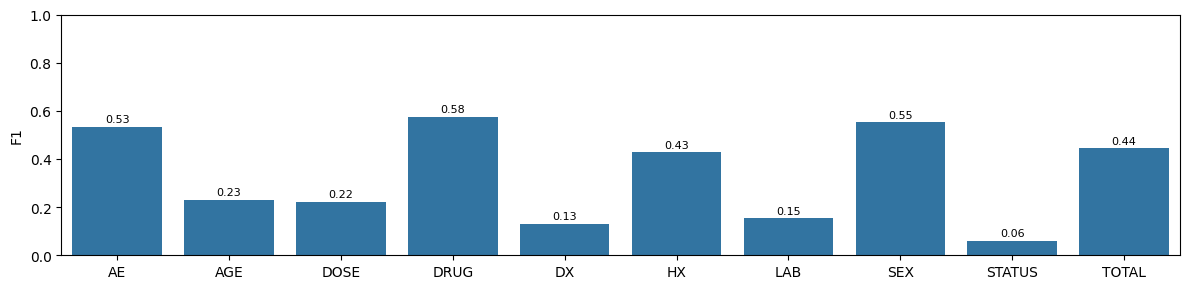

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

## LLM Only
df_fig = df_fig[df_fig['Model']=='LLM']
fig, ax = plt.subplots(figsize=(12, 3))

# --- F1 as bars ---
bar_ax = sns.barplot(
    data=df_fig,
    x='Label_Norm',
    y='F1',
    ax=ax
)

# add F1 value on top of each bar
for container in bar_ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",       # show F1 with 2 decimals
        label_type='edge',
        padding=2,
        fontsize=8
    )


# custom legends
# plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.xlabel('')
plt.tight_layout()
plt.show()


In [25]:
df_fig = df_fig[df_fig['Label_Norm'].isin(['AE','DRUG','DX','HX'])]

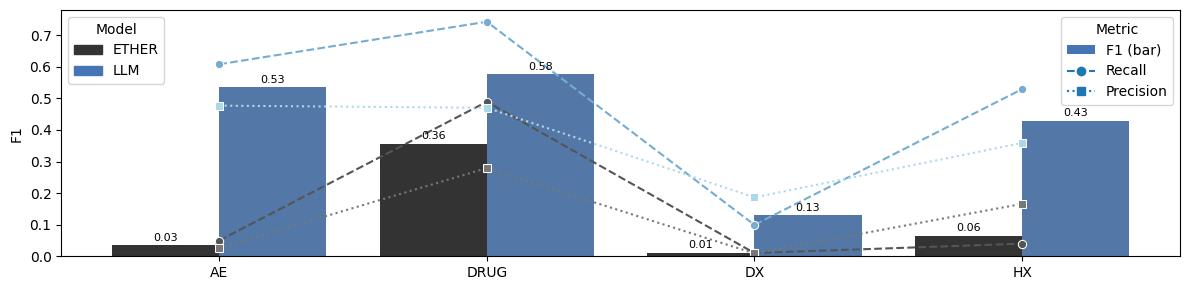

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 3))

# base colors per model
palette_f1 = {'ETHER': '#333333',  # dark red
              'LLM':  '#4575b4'}  # dark blue
palette_recall = {'ETHER': '#555555',
                  'LLM':  '#74add1'}
palette_precision = {'ETHER': '#777777',
                     'LLM':  '#abd9e9'}

# --- F1 as bars ---
bar_ax = sns.barplot(
    data=df_fig,
    x='Label_Norm',
    y='F1',
    hue='Model',
    palette=palette_f1,
    ax=ax
)

# add F1 value on top of each bar
for container in bar_ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",       # show F1 with 2 decimals
        label_type='edge',
        padding=2,
        fontsize=8
    )

# --- Recall as dashed lines with dots ---
sns.lineplot(
    data=df_fig,
    x='Label_Norm',
    y='Recall',
    hue='Model',
    palette=palette_recall,
    linestyle='--',
    marker='o',
    ax=ax,
    legend=False
)

# --- Precision as dotted lines with squares ---
sns.lineplot(
    data=df_fig,
    x='Label_Norm',
    y='Precision',
    hue='Model',
    palette=palette_precision,
    linestyle=':',
    marker='s',
    ax=ax,
    legend=False
)

# custom legends
model_handles = [
    mpatches.Patch(color=palette_f1['ETHER'], label='ETHER'),
    mpatches.Patch(color=palette_f1['LLM'], label='LLM')
]
legend_models = ax.legend(handles=model_handles, title='Model',
                          loc='upper left')

metric_handles = [
    mpatches.Patch(facecolor='#4575b4', label='F1 (bar)'),
    Line2D([0], [0], linestyle='--', marker='o', label='Recall'),
    Line2D([0], [0], linestyle=':', marker='s', label='Precision')
]
legend_metrics = ax.legend(handles=metric_handles, title='Metric',
                           loc='upper right')
ax.add_artist(legend_models)

# plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.tight_layout()
plt.show()
